<a href="https://colab.research.google.com/github/Huii0529/Data-Science-Project/blob/main/P167347_Week14_Plotting_Visualization_20260620.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 14: Plotting and Visualization using Matplotlib**
Please refer to the textbook: "Python for Data Analysis" by Wes McKinney for details of this topic (***Chapter 9***)

## **Overview**

- Data visualisation is an important part of data analysis because it helps us understand patterns, trends, differences between groups, and unusual observations more easily.

- In this notebook, we will learn how to create and customise plots using **Matplotlib**, then briefly explore how **pandas** and **seaborn** can simplify common visualisation tasks.

- The focus of this lesson is not only to produce plots, but also to understand the basic components of a plot, such as the Figure, Axes, title, axis labels, ticks, legend, colours, markers, and subplots.

## **Learning Outcomes**

By the end of this lesson, students should be able to:

1. Explain the difference between a Matplotlib **Figure** and **Axes**.
2. Create basic plots such as line plots, scatter plots, histograms, and bar charts.
3. Customise plots using titles, axis labels, ticks, legends, colours, markers, and line styles.
4. Create multiple plots in one figure using subplots.
5. Save plots into common file formats such as PNG, PDF, and SVG.
6. Use pandas and seaborn to produce common statistical visualisations more efficiently.
7. Interpret basic visual patterns such as trends, distributions, group differences, and relationships between variables.

## **Mount Google Drive**

- This step is only needed if we want to read files from Google Drive or save output files directly to Google Drive.

- If you are running this notebook only for demonstration purposes, this step can be skipped.

In [1]:
# Mount to Google Drive
# This allows Colab to access files stored in your Google Drive
# You can skip this step if you are not reading from or saving to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **From Matplotlib to pandas and seaborn**

Matplotlib is the foundation for many Python plotting tools.
- In this lecture, we first learn the core Matplotlib concepts: Figure, Axes, labels, legends, subplots, and saving plots.
- After that, we briefly explore how pandas and seaborn build on Matplotlib to produce common statistical plots more quickly.

# **Load Required Libraries**

In [2]:
# Load numerical and data manipulation libraries
import numpy as np
import pandas as pd

# Load Matplotlib for basic plotting
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load seaborn for statistical visualisation
import seaborn as sns

# **Part 1: Figure vs Axes**

In Matplotlib, a **Figure** is the entire canvas or page that contains the visualisation.

An **Axes** is the actual plotting area where data is drawn. An Axes usually contains:

- the x-axis;
- the y-axis;
- tick marks;
- tick labels;
- axis labels;
- plot title;
- plotted data.

A single Figure can contain one Axes or multiple Axes.
- When we create subplots, we are placing multiple Axes inside the same Figure.

## **Two ways to use Matplotlib**

Matplotlib can be used in two common ways:

1. **pyplot style**, for example **`plt.plot(...)`**
2. **object-oriented style**, for example **`fig, ax = plt.subplots()`** followed by **`ax.plot(...)`**

- For simple plots, **`plt.plot()`** is convenient.
- For reports, subplots, and customised figures, the object-oriented style is usually clearer because we explicitly control the Figure and Axes.

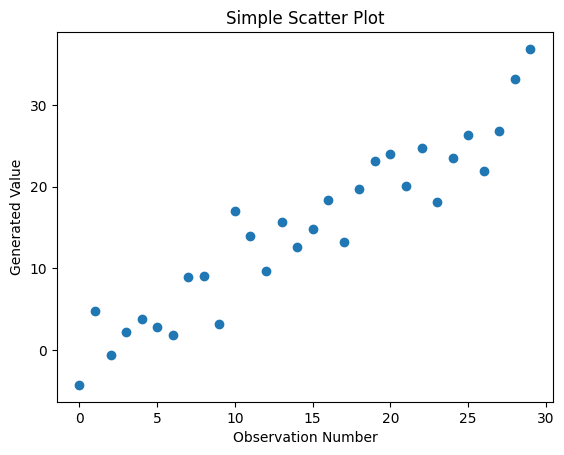

In [3]:
# Create and display a simple scatter plot

# Create x values from 0 to 29
x = np.arange(30)

# Standard normal -> mean of 0, SD of 1
# Create random y values with an upward trend
# The seed number ensures that everyone gets the same random values
rng = np.random.default_rng(12345)
y = x + 3 * rng.standard_normal(30)

# Creates a Figure and Axes using the object-oriented style
fig, ax = plt.subplots()

# Draw the scatter plot
ax.scatter(x, y)

# Add title and axis labels
ax.set(
    title="Simple Scatter Plot",
    xlabel="Observation Number",
    ylabel="Generated Value"
)


plt.show()

### **How to read this plot**

- Each dot represents one observation.

- The x-axis shows the observation number, while the y-axis shows the generated value.

- Although the points do not fall exactly on a straight line, we can still see a general upward trend.

## **Simple 2 × 2 Subplot Grid**

A subplot grid allows us to display several plots in one Figure.
- This is useful when we want to compare different visualisations side by side.

- The argument **`constrained_layout=True`** automatically adjusts spacing between subplots so that titles, labels, and tick labels do not overlap.

- When saving a figure, use **`fig.savefig(...)`** or **`plt.savefig(...)`** before **`plt.show()`** to avoid accidentally saving an empty figure in some environments.

In this example, we use `subplot_mosaic()` to create a 2 × 2 layout.

- The labels `'A'`, `'B'`, `'C'`, and `'D'` are names for the four plotting areas.

- We can then access each subplot using:

```python
mosaic_axs['A']
mosaic_axs['B']
mosaic_axs['C']
mosaic_axs['D']
```

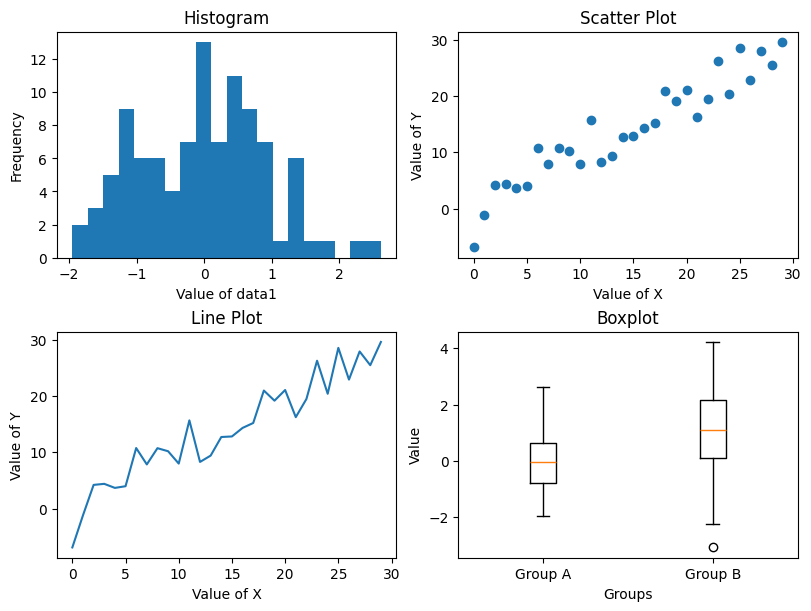

In [4]:
# Create a same random data using 12345 as seed number
rng = np.random.default_rng(12345)

# Creating some data
data1 = rng.normal(0, 1, 100)
data2 = rng.normal(1, 1.5, 100)
x = np.arange(30)
y = x + rng.normal(0, 3, 30)

# Using subplot_mosaic to define a 2x2 grid
fig, mosaic_axs = plt.subplot_mosaic([['A', 'B'], ['C', 'D']],
                                     figsize=(8, 6),
                                     constrained_layout=True)

# (1) Histogram
mosaic_axs['A'].hist(data1, bins=20)
mosaic_axs['A'].set_title("Histogram")
mosaic_axs['A'].set_xlabel("Value of data1")
mosaic_axs['A'].set_ylabel("Frequency")

# (2) Scatter plot
mosaic_axs['B'].scatter(x, y)
mosaic_axs['B'].set_title("Scatter Plot")
mosaic_axs['B'].set_xlabel("Value of X")
mosaic_axs['B'].set_ylabel("Value of Y")

# (3) Line plot
mosaic_axs['C'].plot(x, y)
mosaic_axs['C'].set_title("Line Plot")
mosaic_axs['C'].set_xlabel("Value of X")
mosaic_axs['C'].set_ylabel("Value of Y")

# (4) Boxplot
mosaic_axs['D'].boxplot([data1, data2], tick_labels=["Group A", "Group B"])
mosaic_axs['D'].set_title("Boxplot")
mosaic_axs['D'].set_xlabel("Groups")
mosaic_axs['D'].set_ylabel("Value")

# To save the figures
# Figs_Combo.pdf is your chosen file name
# The directory needs to change accordingly
# If you are running this in Jupyter Notebook or on your own computer,
# change the directory path accordingly
plt.savefig('/content/Figs_subplots.pdf')

#plt.show()

# **Customising Individual Plots**

In this section, we learn how to customise common plot elements such as **bins, transparency, line style, colour, marker, ticks, labels, and legends.**

### **Histogram**


*   **`bins`**: Bins are the intervals into which the data is divided for counting and display in the histogram.
    - Having 20 bins means the data range will be split into 20 intervals
*   **`alpha`**: controls the transparency of the bars.
    - A value of 1.0 would be completely opaque, while 0.0 would be completely transparent.



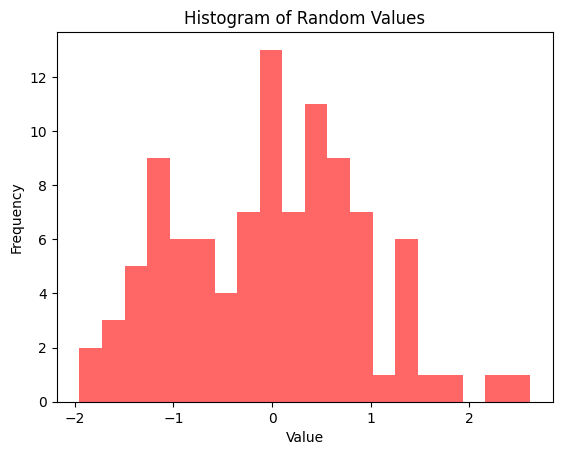

In [8]:
# Histogram
rng = np.random.default_rng(12345)
plt.hist(rng.standard_normal(100),
         bins=20,
         color='red',
         alpha=0.6 # Transparency
)

# Final exam must have these 3 items (title, x-label, and y-label)
plt.title("Histogram of Random Values")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

### **Interpretation**

The histogram shows how the generated values are distributed.

- Most values are concentrated around the centre, while fewer values appear at the extreme left and right sides.

### **Line Style**
1. Some common options:

*   `'-'` (**solid**): This is the default linestyle and creates a solid line.
*   `'--'` (**dashed**): Creates a dashed line.
*   `'-.'` (**dash-dot**): Creates a line with alternating dashes and dots.
*   `':'` (**dotted**): Creates a dotted line.
* `None`, `' '`, or `''`: no line is drawn. This is useful when we want to show markers only.

2. We can also use:
*   **`solid`**: `-`
*   **`dashed`**: `--`
*   **`dashdot`**: `-.`
*   **`dotted`**: `:`

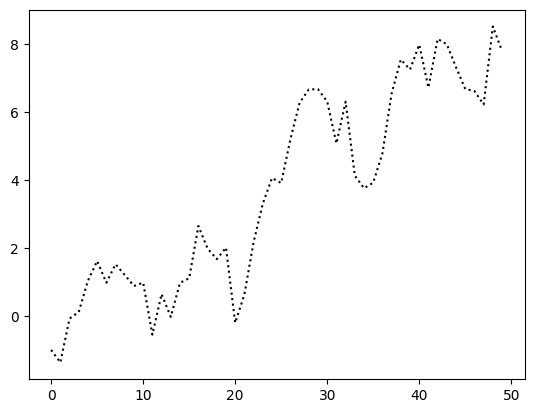

In [14]:
# Line plot
rng = np.random.default_rng(123)
plt.plot(rng.standard_normal(50).cumsum(), # Cumulative sum
         color='black', linestyle=':');

### **Colours, Markers, and Line Styles**

Matplotlib allows us to customise the appearance of a plot using:

- **`color`**: controls the colour of the line or marker.
- **`linestyle`**: controls the type of line, such as solid, dashed, dotted, or dash-dot.
- **`marker`**: controls the symbol used to mark each data point.

Colours can be specified using common colour names
- short colour codes such as **`'r'`** for red, or hex colour codes such as **`#CECECE`**.

* For more information about hex colour codes, can visit this website: https://htmlcolorcodes.com/



### **Marker**
- A marker is a symbol placed at each data point on a line plot.
- Markers are useful when we want to clearly show the individual observations that make up a line.

### **Other Marker Options**

Matplotlib offers a wide variety of marker options. Here are a few examples:

* `'.'`: Point
* `','`: Pixel
* `'o'`: Circle
* `'v'`: Triangle down
* `'^'`: Triangle up
* `'<'`: Triangle left
* `'>'`: Triangle right
* `'s'`: Square
* `'+'`: Plus
* `'x'`: X
* `'D'`: Diamond
* `'d'`: Thin diamond
* `'|'`: Vertical line
* `'_'`: Horizontal line

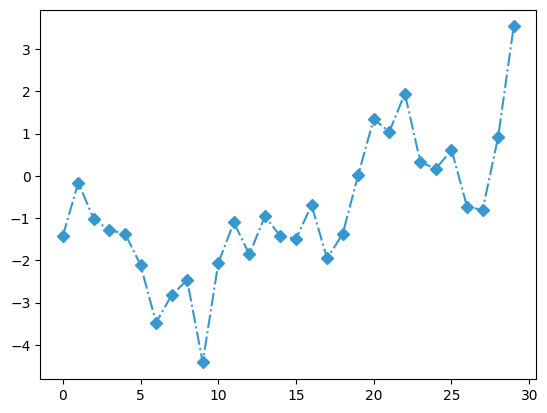

In [ ]:
# Adding marker on line plot
rng = np.random.default_rng(12345)
plt.plot(rng.standard_normal(30).cumsum(), color='#3698CF',
        linestyle='-.', marker='D');

### **Comment on the Plot**

The plot above is incomplete because it does not include:

- a clear title;
- an x-axis label;
- a y-axis label;
- a short explanation of what the line represents.

<font color='red'>**A good plot should be understandable even when viewed separately from the code.**</font>

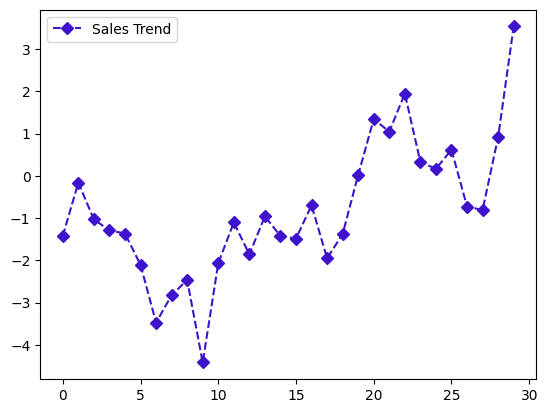

In [ ]:
# Drawstyle default
rng = np.random.default_rng(12345)
data = rng.standard_normal(30).cumsum()
plt.plot(data, color='#3F12CC', linestyle='dashed', label='Sales Trend', marker='D')
plt.legend();

### **Setting the Title, Axis Labels, Ticks, and Tick Labels**

- Ticks are the positions shown on an axis.

- Tick labels are the text displayed at those positions.

- When setting custom tick labels, the number of labels must match the number of tick positions.

- For example, if we define five tick positions, we must also provide five tick labels.

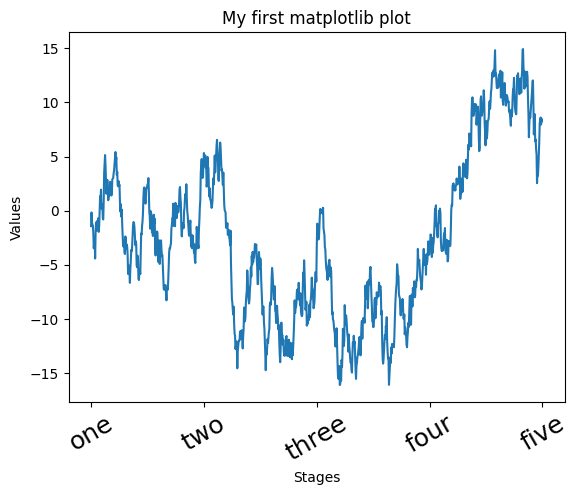

In [15]:
# An example
rng = np.random.default_rng(12345)
fig, ax = plt.subplots()
ax.plot(rng.standard_normal(1000).cumsum())

# Change the x-axis tick positions
ax.set_xticks([0, 250, 500, 750, 1000])

# label the x-axis ticks with names
ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],
                   rotation=30, fontsize=18)

ax.set_xlabel('Stages')
ax.set_ylabel('Values')
ax.set_title('My first matplotlib plot');

### **Adding Legends**

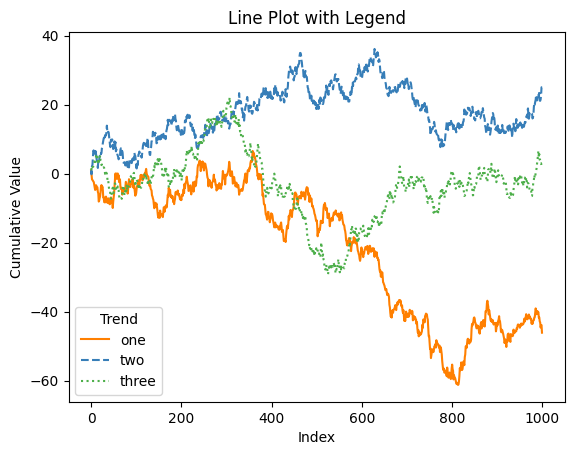

In [19]:
# Adding a legend

# The lines will change every time we re-run this cell
# because we are using np.random.randn() without setting a seed.

fig, ax = plt.subplots()

ax.plot(np.random.randn(1000).cumsum(), color='#FF7F00', label='one')
ax.plot(np.random.randn(1000).cumsum(), color='#377EB8', linestyle='dashed',
        label='two')
ax.plot(np.random.randn(1000).cumsum(), color='#4DAF4A', linestyle='dotted',
        label='three')

ax.set_title("Line Plot with Legend")
ax.set_xlabel("Index")
ax.set_ylabel("Cumulative Value")

ax.legend(title='Trend')

plt.show()

### **Reproducible version**

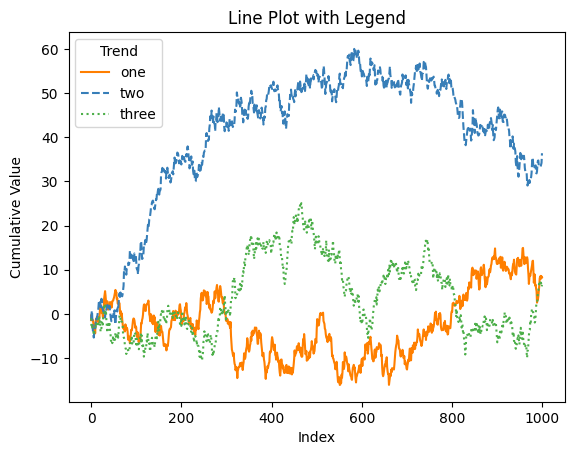

In [20]:
# Adding a legend with reproducible random data

rng = np.random.default_rng(12345)

fig, ax = plt.subplots()

ax.plot(rng.standard_normal(1000).cumsum(), color='#FF7F00', label='one')
ax.plot(rng.standard_normal(1000).cumsum(), color='#377EB8', linestyle='dashed', label='two')
ax.plot(rng.standard_normal(1000).cumsum(), color='#4DAF4A', linestyle='dotted', label='three')

ax.set_title("Line Plot with Legend")
ax.set_xlabel("Index")
ax.set_ylabel("Cumulative Value")

ax.legend(title='Trend')

plt.show()

### **Adding Shapes to a Plot**

Matplotlib can also add geometric shapes such as rectangles, circles, polygons, ellipses, and regular polygons.
- These are useful for **annotation, highlighting regions, or creating custom diagrams**.

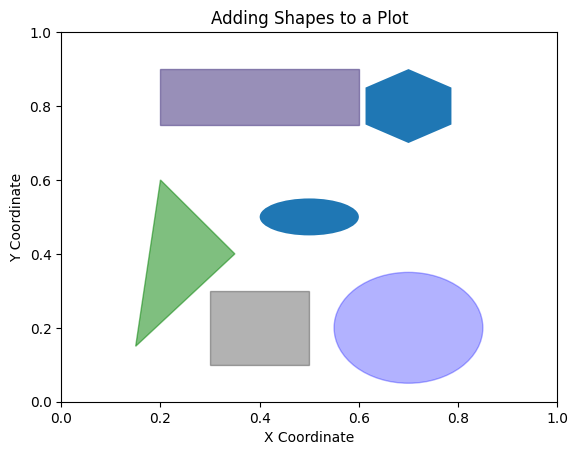

In [24]:
# Adding shapes to a plot
fig, ax = plt.subplots()

# Create different shapes
rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='#54458A', alpha=0.6)
circ = plt.Circle((0.7, 0.2), 0.15, color='blue', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='green', alpha=0.5)
sqr = plt.Rectangle((0.3, 0.1), 0.2, 0.2, color='black', alpha=0.3)

# Add ellipse
ellipse = patches.Ellipse((0.5,0.5), 0.2, 0.1)

# Add regular hexagon
hexagon = patches.RegularPolygon((0.7,0.8), 6, radius=0.1)

# Add the shapes to the Axes
ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)
ax.add_patch(sqr)
ax.add_patch(ellipse)
ax.add_patch(hexagon)

# Set the display range
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Add title and labels
ax.set_title("Adding Shapes to a Plot")
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")

plt.show()

### **Explanation**

Each shape is placed using x and y coordinates.

For example, `plt.Rectangle((0.2, 0.75), 0.4, 0.15)` means:

- the rectangle starts at x = 0.2 and y = 0.75;
- the width is 0.4;
- the height is 0.15.

- Shapes are useful when we want to highlight areas or create simple diagrams inside a plot.

### **Saving Plots to File**

Matplotlib allows us to save plots in different file formats, such as:

- `.png`
- `.jpeg`
- `.pdf`
- `.svg`
- `.eps`

For reports and assignments:

- use `.png` or `.jpeg` for images;
- use `.pdf` for high-quality documents;
- use `.svg` when you need a scalable vector graphic.

In [25]:
# Save the current figure
fig.savefig(
    '/content/shapes_subplots.jpeg',
    dpi=300,
    bbox_inches="tight"
)

### **Notes:**
If you are **not using Google Colab** and want to save the file to **some other places**, replace `'shapes_subplots.jpeg'` with your **own directory path**.

### **Matplotlib Configuration**

Matplotlib allows us to change default settings using `plt.rc()`.

For example:

```python
plt.rc('figure', figsize=(10, 10))
```
- sets the default figure size to 10 × 10 inches for plots created after this line

- This changes the default figure size for plots created after this line.

- **<font color='red'>Be careful</font>**: this setting remains active until we change it again or reset Matplotlib to its default settings.

In [26]:
# Set the previous shapes figure to 5 x 5
plt.rc('figure', figsize=(5, 5))

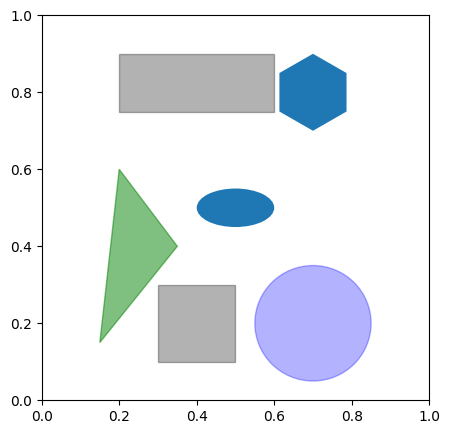

In [27]:
# Adding shapes to a plot : Attention
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='black', alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color='blue', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='green', alpha=0.5)
sqr = plt.Rectangle((0.3, 0.1), 0.2, 0.2, color='black', alpha=0.3)

# Add ellipse
ellipse = patches.Ellipse((0.5,0.5),0.2,0.1)

# Add regular hexagon
hexagon = patches.RegularPolygon((0.7,0.8),6, radius=0.1)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)
ax.add_patch(sqr)
ax.add_patch(ellipse)
ax.add_patch(hexagon);

### **To reset Matplotlib to its default settings, use:**

In [28]:
# Reset to default value
plt.rcdefaults()

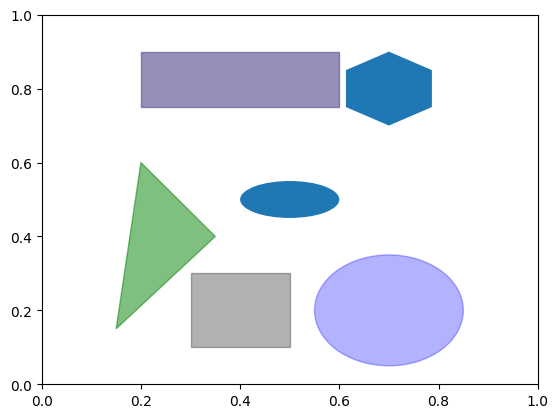

In [29]:
# Adding shapes to a plot
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color='#54458A', alpha=0.6)
circ = plt.Circle((0.7, 0.2), 0.15, color='blue', alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color='green', alpha=0.5)
sqr = plt.Rectangle((0.3, 0.1), 0.2, 0.2, color='black', alpha=0.3)

# Add ellipse
ellipse = patches.Ellipse((0.5,0.5), 0.2, 0.1)

# Add regular hexagon
hexagon = patches.RegularPolygon((0.7,0.8), 6, radius=0.1)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)
ax.add_patch(sqr)
ax.add_patch(ellipse)
ax.add_patch(hexagon);

## **Part 2: Plotting with pandas and seaborn**

So far, we used Matplotlib directly.

In practice, we often use pandas and seaborn to create common plots more quickly.

- **pandas plotting** is convenient when the data is already stored in a Series or DataFrame.
- **seaborn** is useful for statistical visualisation, especially when comparing groups or exploring relationships between variables.

Although pandas and seaborn simplify plotting, they are still built on top of Matplotlib. Therefore, understanding Matplotlib helps us customise plots more effectively.


### **Line plots**

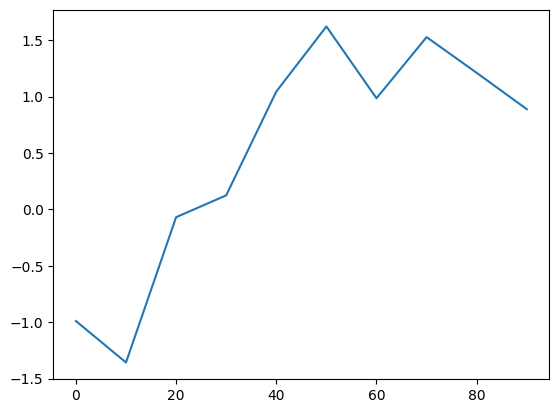

In [30]:
# Using series data
rng = np.random.default_rng(123)
s = pd.Series(rng.standard_normal(10).cumsum(),
              index=np.arange(0, 100, 10))
s.plot();

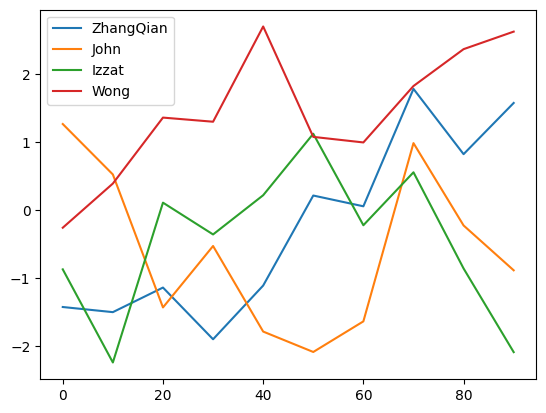

In [31]:
# Using DataFrame
rng = np.random.default_rng(12345)
df = pd.DataFrame(rng.standard_normal((10, 4)).cumsum(0),
                  columns=['ZhangQian', 'John', 'Izzat', 'Wong'],
                  index=np.arange(0, 100, 10))
#df
df.plot();

### **Bar plots**

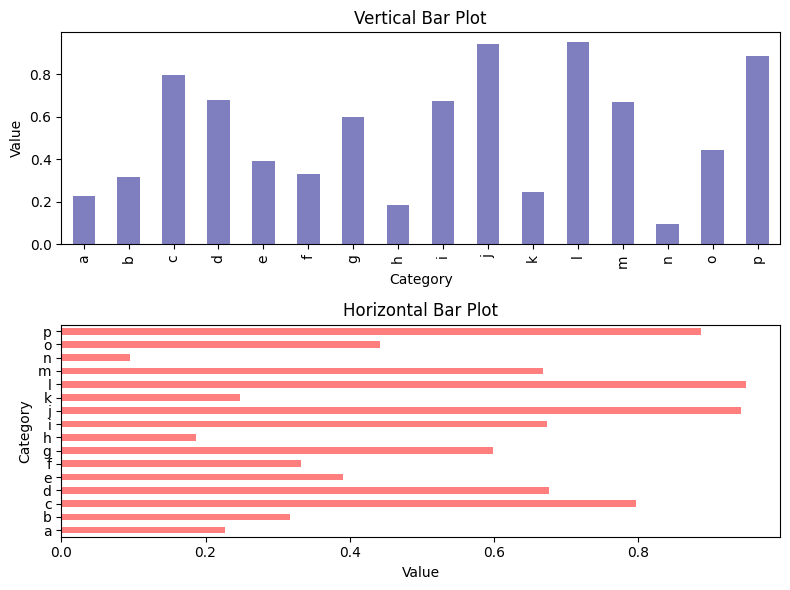

In [32]:
# Series bar plot

rng = np.random.default_rng(12345)

fig, axes = plt.subplots(2, 1, figsize=(8, 6))

data = pd.Series(
    rng.uniform(size=16),
    index=list('abcdefghijklmnop')
)

# Vertical bar plot
data.plot.bar(ax=axes[0], color='navy', alpha=0.5)
axes[0].set_title("Vertical Bar Plot")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Value")

# Horizontal bar plot
data.plot.barh(ax=axes[1], color='red', alpha=0.5)
axes[1].set_title("Horizontal Bar Plot")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.show()

- Vertical Bar - for x-axes label that not longer word
- Horizontall bar - suitable for the x-axes label with the longer words

In [33]:
# Example DataFrame
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=['one', 'two', 'three', 'four', 'five', 'six'],
                  columns=pd.Index(['A', 'B', 'C', 'D'], name='Genus'))
df

Genus,A,B,C,D
one,0.299358,0.974686,0.961430,0.253264
two,0.250948,0.461279,0.583397,0.163317
three,0.790904,0.190884,0.504795,0.230822
four,0.472522,0.050485,0.391636,0.991125
five,0.573221,0.655480,0.354266,0.487777
six,0.188463,0.474752,0.565821,0.501937


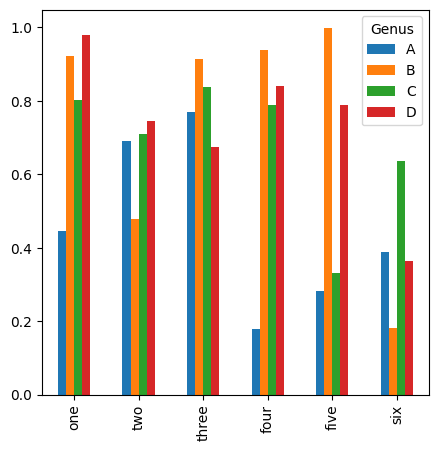

In [ ]:
# Grouped bar plot
df.plot.bar();

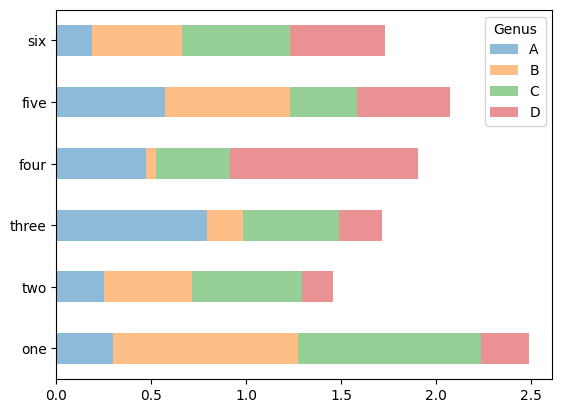

In [35]:
# Stacked bar plots
df.plot.barh(stacked=True, alpha=0.5);

## **Using the Tips Dataset**

The tips dataset contains information about restaurant bills and tips.

Each row represents one restaurant bill.

Some important variables include:

- `total_bill`: total amount of the bill;
- `tip`: amount of tip given;
- `sex`: sex of the customer;
- `smoker`: whether the customer is a smoker;
- `day`: day of the week;
- `time`: lunch or dinner;
- `size`: number of people in the dining party.

In [36]:
# Load the tips dataset from an online source
tips = pd.read_csv('https://bit.ly/3jCROII')

In [37]:
# Display the tips dataset
tips

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4
...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3
240,27.18,2.00,Yes,Sat,Dinner,2
241,22.67,2.00,Yes,Sat,Dinner,2
242,17.82,1.75,No,Sat,Dinner,2


### **Create a Frequency Table**

- A frequency table counts how many observations fall into each category.

- Here, we count how many dining parties of different sizes appear on each day.

In [38]:
# Define logical order for days
day_order = ['Thur', 'Fri', 'Sat', 'Sun']

# Convert day column into ordered categorical type
tips['day'] = pd.Categorical(tips['day'], categories=day_order, ordered=True)

# Create a frequency table
party_counts = pd.crosstab(tips['day'], tips['size'], margins=True)
party_counts

size,1,2,3,4,5,6,All
day,,,,,,,
Thur,1,48,4,5,1,3,62
Fri,1,16,1,1,0,0,19
Sat,2,53,18,13,1,0,87
Sun,0,39,15,18,3,1,76
All,4,156,38,37,5,4,244


### **Interpretation**

- Each row represents a day.

- Each column represents the number of people in the dining party.

- The values show how many times each party size appears on each day.

In [39]:
# Reorder the index
party_counts = party_counts.reindex(index=['Thur', 'Fri', 'Sat', 'Sun'])
party_counts

size,1,2,3,4,5,6,All
day,,,,,,,
Thur,1,48,4,5,1,3,62
Fri,1,16,1,1,0,0,19
Sat,2,53,18,13,1,0,87
Sun,0,39,15,18,3,1,76


In [42]:
# Extract party_count from col 2 to 5
# function loc -> using label based
party_counts = party_counts.loc[:, 2:5]

In [43]:
# Display party_counts
# These are absolute counts
party_counts

size,2,3,4,5
day,,,,
Thur,48,4,5,1
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3


### **Convert Counts into Proportions**

The original table shows absolute counts.

- To compare the pattern across days more fairly, we convert the counts into proportions.

- This means each row will sum to 1.

In [44]:
# Normalize each row to sum to 1
party_pcts = party_counts.div(party_counts.sum(axis='columns'), # calculates the total for each row
                              axis=0) # divides each value in the row by the row total
party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


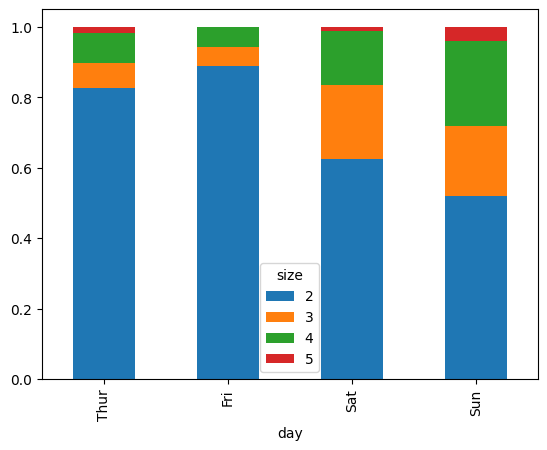

In [45]:
# Stacked bar plot
party_pcts.plot.bar(stacked=True);

# **Part 3: Introduction to Seaborn**

Seaborn is a statistical visualisation library built on top of Matplotlib.

It is especially useful when we want to:

- compare groups;
- visualise distributions;
- add confidence intervals;
- use categorical variables such as `day`, `time`, or `smoker`;
- create attractive statistical plots with less code.

### **Using seaborn package**

In [46]:
# Show content for tips
tips

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4
...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3
240,27.18,2.00,Yes,Sat,Dinner,2
241,22.67,2.00,Yes,Sat,Dinner,2
242,17.82,1.75,No,Sat,Dinner,2


In [47]:
# Add a new column for 'tip_pct'
tips['tip_pct'] = tips['tip'] / tips['total_bill']

In [48]:
# Show top five rows
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.059447
1,10.34,1.66,No,Sun,Dinner,3,0.160542
2,21.01,3.50,No,Sun,Dinner,3,0.166587
3,23.68,3.31,No,Sun,Dinner,2,0.139780
4,24.59,3.61,No,Sun,Dinner,4,0.146808


### **Notes on `sns.barplot()`**

In `sns.barplot()`, the height or length of each bar usually represents the **<font color='red'>mean value</font>** for each category.

The black error bars show uncertainty around the estimated mean.

By default, seaborn displays a 95% confidence interval.

A simple way to understand this is:

- the bar shows the average value;
- the error bar shows how much uncertainty there is around that average;
- a longer error bar means more uncertainty;
- a shorter error bar means less uncertainty.

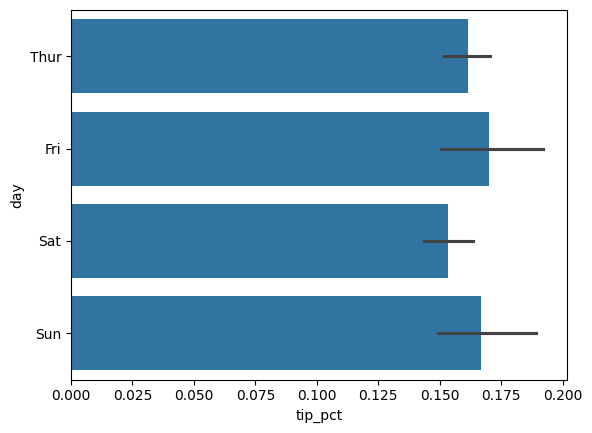

In [49]:
# Using black lines on the bars to represent 95% confidence interval
sns.barplot(x='tip_pct', y='day', data=tips, orient='h',
            order=['Thur', 'Fri', 'Sat', 'Sun']);

### **`hue`**
- `hue` helps to visualize the impact of an **additional categorical variable** on our main comparison.

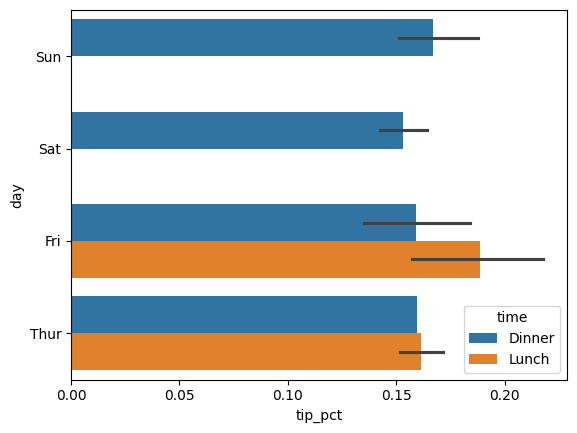

In [50]:
# Using hue to add a categorical distinction
sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h',
            order=['Sun', 'Sat', 'Fri', 'Thur']);

### **Histograms and Density Plots**

- A **histogram** divides a **numerical variable** into intervals called bins and counts how many observations fall into each bin.

- A **density plot** shows a smoothed estimate of the distribution. It is useful for understanding the overall shape of the data.

In [51]:
# Display top few rows
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.059447
1,10.34,1.66,No,Sun,Dinner,3,0.160542
2,21.01,3.50,No,Sun,Dinner,3,0.166587
3,23.68,3.31,No,Sun,Dinner,2,0.139780
4,24.59,3.61,No,Sun,Dinner,4,0.146808


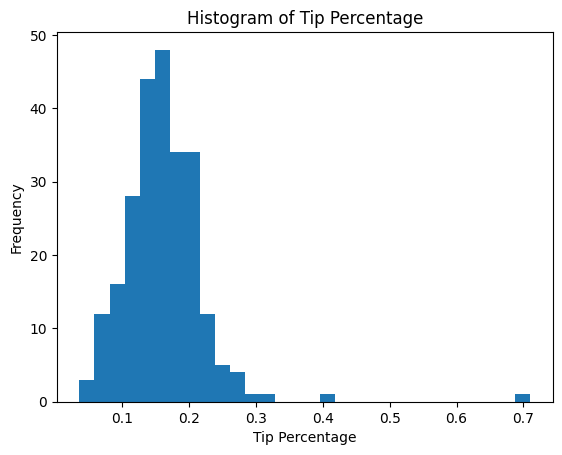

In [52]:
# Histogram of tip percentage

tips['tip_pct'].plot.hist(bins=30)

plt.title("Histogram of Tip Percentage")
plt.xlabel("Tip Percentage")
plt.ylabel("Frequency")

plt.show()

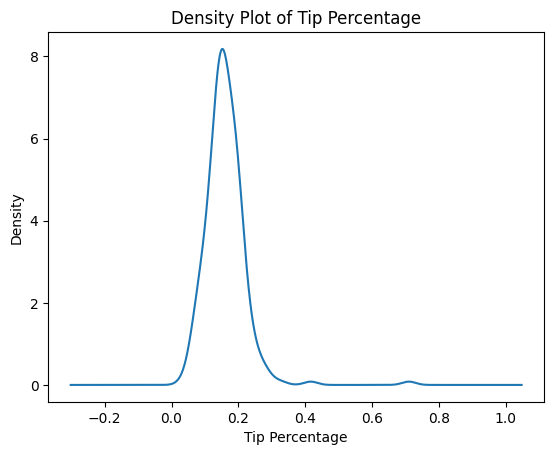

In [53]:
# Density plot of tip percentage

tips['tip_pct'].plot.density()

plt.title("Density Plot of Tip Percentage")
plt.xlabel("Tip Percentage")

plt.show()

### **Histogram vs Density Plot**

- A histogram shows the actual frequency of observations within bins.

- A density plot shows a smoothed version of the distribution.

- The density plot is useful for seeing the overall shape, but it does not show the raw counts directly.

### **Notes**:
- Density plot **estimates the overall shape of the distribution** using smoothing
- Density plot **smooths over the individual bars, so small fluctuations in the histogram may disappear**
- smoothing -> making a rough, noisy pattern look more like a clear overall trend

### **Scatter or Point Plots**
- examining the relationship between two one-dimensional data series

## **Scatter Plots with Economic Data**

After exploring categorical and distribution plots using the tips dataset, we now use a macroeconomic dataset to study relationships between numerical variables.

This allows us to practise scatter plots, regression lines, correlation, and pair plots.

#### **Macro dataset**
- Collection of economic data points that reflect the overall performance and health of a country, region, or the global economy.
- **`m1`** represents the M1 money supply
    - a measure of the most liquid forms of money within an economy, typically including physical currency (cash), demand deposits (checking accounts), and traveler's checks.
- **`tbilrate`** is Treasury Bill Rate.
    - the interest rate at which the government borrows money for short periods (usually less than a year) by issuing Treasury Bills.

In [54]:
# Example macro dataset
macro = pd.read_csv('https://bit.ly/3FYxCYZ')
macro

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008,3,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008,4,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009,1,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009,2,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [55]:
# Only select a few variables
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
data

,cpi,m1,tbilrate,unemp
0,28.980,139.7,2.82,5.8
1,29.150,141.7,3.08,5.1
2,29.350,140.5,3.82,5.3
3,29.370,140.0,4.33,5.6
4,29.540,139.6,3.50,5.2
...,...,...,...,...
198,216.889,1474.7,1.17,6.0
199,212.174,1576.5,0.12,6.9
200,212.671,1592.8,0.22,8.1
201,214.469,1653.6,0.18,9.2


# **Log Transformation**

A log transformation is often used for economic or financial variables because it can reduce the influence of very large values.

In this example, we apply:

```python
np.log(data).diff().dropna()
```

This means:

- `np.log(data)` transforms the original values using the natural logarithm.
- `.diff()` calculates the change from one row to the next.
- `.dropna()` removes the first row because differencing creates a missing value.

In simple terms, this helps us study changes in the variables rather than their original levels.

In [56]:
# Applies a logarithmic transformation
# Calculates the difference between consecutive values
# Removes any rows with missing values (NaN)
logtrans_data = np.log(data).diff().dropna()

# Display content
logtrans_data

,cpi,m1,tbilrate,unemp
1,0.005849,0.014215,0.088193,-0.128617
2,0.006838,-0.008505,0.215321,0.038466
3,0.000681,-0.003565,0.125317,0.055060
4,0.005772,-0.002861,-0.212805,-0.074108
5,0.000338,0.004289,-0.266946,0.000000
...,...,...,...,...
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339


In [57]:
# Display top few rows for data
data.head()

,cpi,m1,tbilrate,unemp
0,28.98,139.7,2.82,5.8
1,29.15,141.7,3.08,5.1
2,29.35,140.5,3.82,5.3
3,29.37,140.0,4.33,5.6
4,29.54,139.6,3.50,5.2


In [58]:
# Display contents for logtrans_data
logtrans_data

,cpi,m1,tbilrate,unemp
1,0.005849,0.014215,0.088193,-0.128617
2,0.006838,-0.008505,0.215321,0.038466
3,0.000681,-0.003565,0.125317,0.055060
4,0.005772,-0.002861,-0.212805,-0.074108
5,0.000338,0.004289,-0.266946,0.000000
...,...,...,...,...
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339


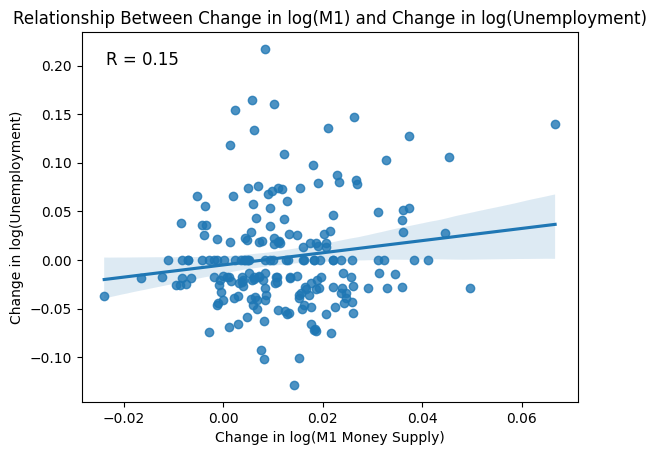

In [59]:
# Generate scatter plot with regression line

fig, ax = plt.subplots()

sns.regplot(
    x='m1',
    y='unemp',
    data=logtrans_data,
    ax=ax
)

# Calculate the correlation coefficient
r_value = logtrans_data['m1'].corr(logtrans_data['unemp'])

# Add the R-value to the plot
ax.text(
    0.05,
    0.95,
    f'R = {r_value:.2f}',
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top'
)

# Add title and axis labels
ax.set_title('Relationship Between Change in log(M1) and Change in log(Unemployment)')
ax.set_xlabel('Change in log(M1 Money Supply)')
ax.set_ylabel('Change in log(Unemployment)')

plt.show()

### **Interpretation**

The regression line summarises the general relationship between the two variables.

The R-value measures the strength and direction of the linear relationship.

- A positive R-value means both variables tend to increase together.
- A negative R-value means one variable tends to increase when the other decreases.
- An R-value close to 0 means there is little linear relationship.

### **Pair Plot**

A pair plot allows us to compare several numerical variables at once.

- The diagonal plots show the distribution of each variable.
- The off-diagonal plots show relationships between pairs of variables.
- `kind='reg'` adds a regression line to each scatter plot.
- `diag_kind='kde'` shows density plots on the diagonal.

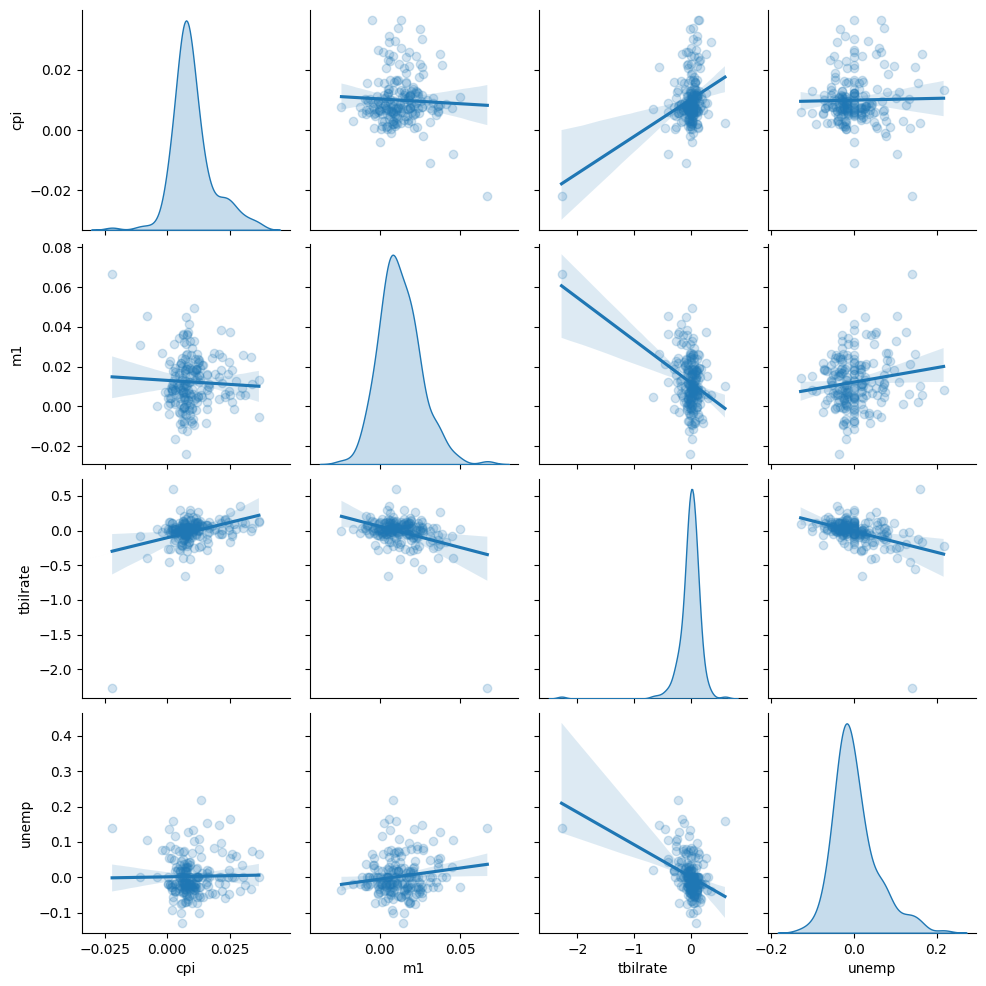

In [60]:
# kde = kernel density estimate - another name for density plot
# Estimate of the continuous probability distribution
# `scatter_kws` -> scatter keyword arguments
sns.pairplot(logtrans_data, diag_kind='kde', kind='reg',
             plot_kws={'scatter_kws': {'alpha': 0.2}});

### **Facet Grids and Categorical Data**

A facet is a small plot created for a subgroup of the data.

- Faceting is useful when we want to compare patterns across categories.

In seaborn:

- `row` creates separate plots arranged by row;
- `col` creates separate plots arranged by column;
- `hue` separates data using colour;
- `kind` controls the type of plot, such as bar plot or boxplot.

For example, we can compare tipping behaviour by day, time, and smoker status.

In [61]:
# Display contents for tips dataframe
tips

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.059447
1,10.34,1.66,No,Sun,Dinner,3,0.160542
2,21.01,3.50,No,Sun,Dinner,3,0.166587
3,23.68,3.31,No,Sun,Dinner,2,0.139780
4,24.59,3.61,No,Sun,Dinner,4,0.146808
...,...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3,0.203927
240,27.18,2.00,Yes,Sat,Dinner,2,0.073584
241,22.67,2.00,Yes,Sat,Dinner,2,0.088222
242,17.82,1.75,No,Sat,Dinner,2,0.098204


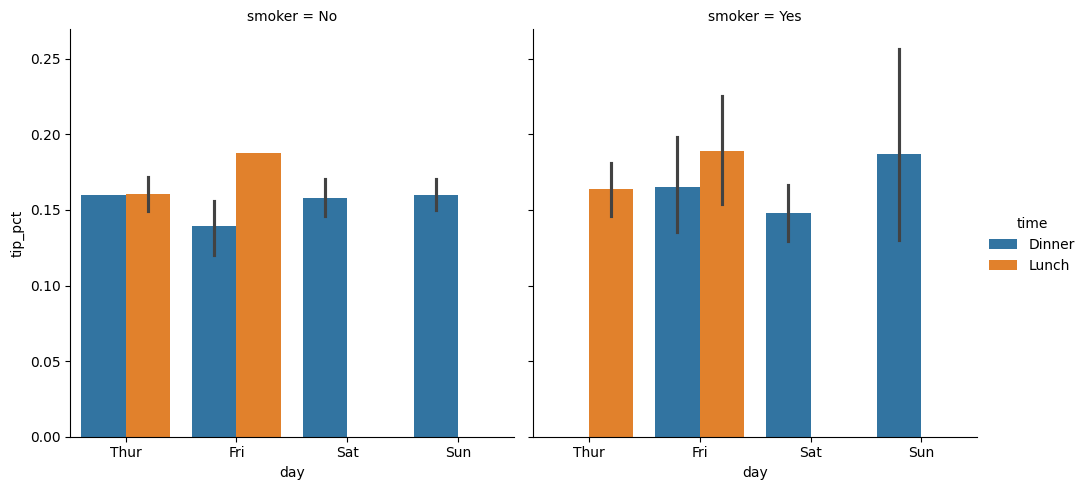

In [62]:
# Generate categorical plot
# col='smoker' -> plots will be arranged in columns based on smoker status
sns.catplot(x='day', y='tip_pct', hue='time', col='smoker',
            kind='bar', data=tips[tips.tip_pct < 1],
            order=['Thur', 'Fri', 'Sat', 'Sun']);

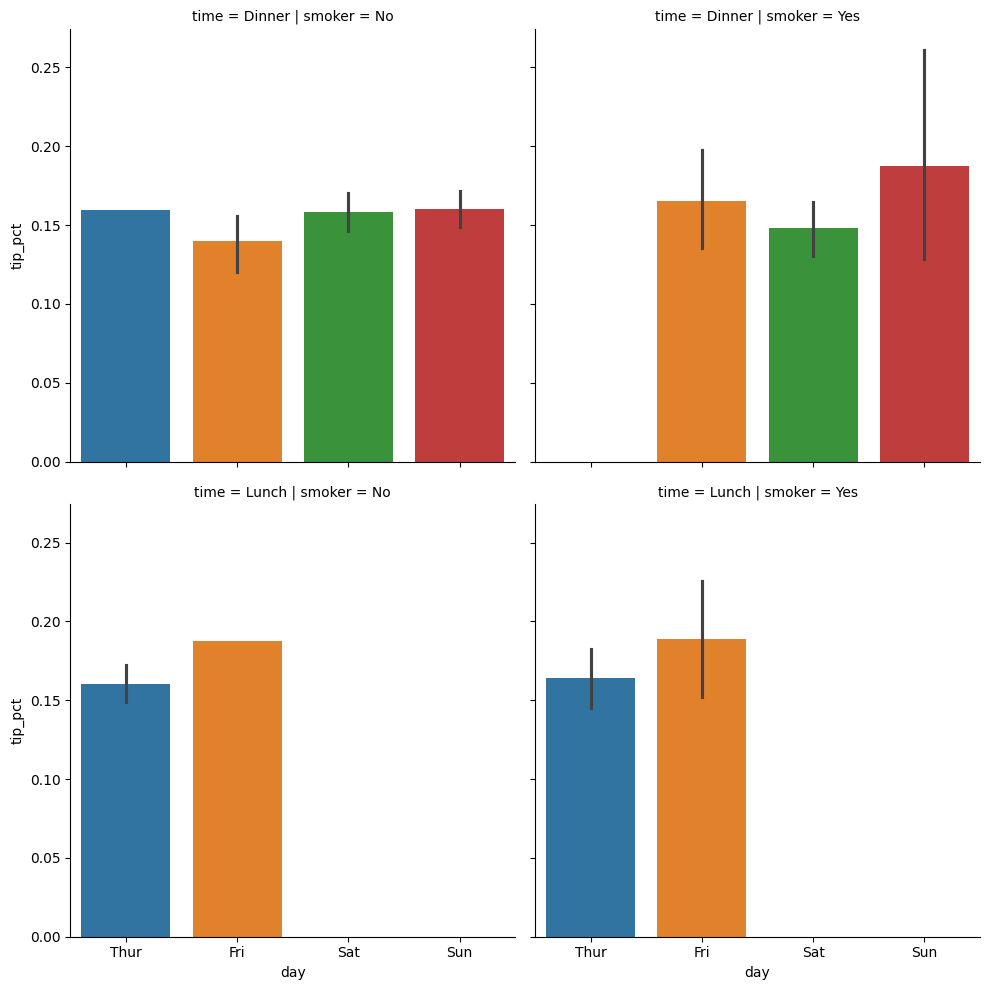

In [63]:
# Generate categorical plot
sns.catplot(x='day', y='tip_pct', row='time',
            col='smoker', hue='day', order=['Thur', 'Fri', 'Sat', 'Sun'],
            kind='bar', data=tips[tips.tip_pct < 1]);

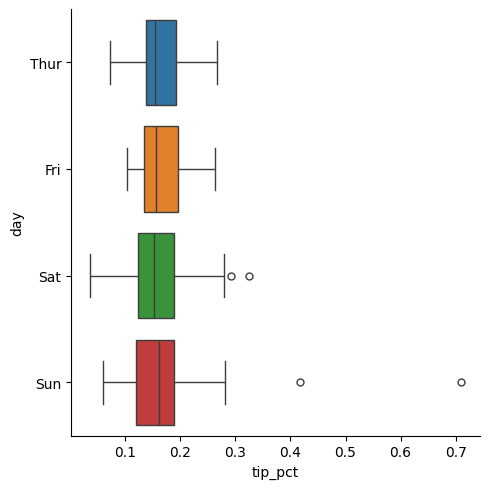

In [65]:
# Generate categorical plot: boxplot
sns.catplot(x='tip_pct', y='day', hue='day', kind='box',
            data=tips[tips.tip_pct < 0.8], order=['Thur', 'Fri', 'Sat', 'Sun']);

# **Summary**

In this lesson, we learned how to:

- create basic plots using Matplotlib;
- understand the difference between Figure and Axes;
- customise plots using titles, labels, ticks, colours, markers, line styles, and legends;
- arrange multiple plots using subplots;
- save figures to external files;
- use pandas and seaborn to create common statistical visualisations more efficiently;
- interpret basic visual patterns such as trends, distributions, group differences, and relationships between variables.

The key idea is that **Matplotlib provides the foundation**, while **pandas and seaborn provide convenient shortcuts** for common plotting tasks.

- **A good visualisation should not only look nice, but should also communicate the message of the data clearly**.